# Notebook 01 — Exploratory Data Analysis

**Data source:** `main_marts.fct_enrollment_outcomes` (DuckDB)  
**Purpose:** Understand the class imbalance, identify key dropout signals, and surface feature patterns that will inform modeling decisions in notebooks 02 and 03.

**Narrative arc:**
1. Load from mart layer
2. Class distribution: understand the imbalance problem
3. Academic performance signals: strongest predictors
4. Financial signals: tuition and scholarship effects
5. Demographic patterns
6. Correlation structure
7. EDA summary: modeling implications

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Class color palette — used consistently throughout
CLASS_COLORS = {
    'Dropout':  '#378ADD',
    'Enrolled': '#D85A30',
    'Graduate': '#639922'
}
CLASS_ORDER = ['Dropout', 'Enrolled', 'Graduate']

## 1. Load from mart layer

All analysis starts from `fct_enrollment_outcomes`, the output of the dbt pipeline. No raw CSV reads.

In [2]:
con = duckdb.connect('../data/student_dropout.duckdb')

df = con.execute("""
    SELECT
        f.*,
        p.course_name,
        p.attendance_label
    FROM main_marts.fct_enrollment_outcomes f
    LEFT JOIN main_intermediate.int_program_context p
        ON f.program_key = p.program_key
""").df()

con.close()

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (4424, 44)
Columns: ['student_key', 'program_key', 'economic_context_key', 'application_mode', 'application_order', 'previous_qualification', 'previous_qualification_grade', 'admission_grade', 'is_scholarship_holder', 'tuition_fees_up_to_date', 'is_debtor', 'age_at_enrollment', 'gender', 'gender_label', 'nationality', 'is_international', 'is_displaced', 'has_special_needs', 'marital_status', 'marital_status_label', 'mothers_qualification', 'fathers_qualification', 'mothers_occupation', 'fathers_occupation', 'unemployment_rate', 'inflation_rate', 'gdp', 'sem1_units_credited', 'sem1_units_enrolled', 'sem1_evaluations', 'sem1_units_approved', 'sem1_grade', 'sem1_units_no_eval', 'sem2_units_credited', 'sem2_units_enrolled', 'sem2_evaluations', 'sem2_units_approved', 'sem2_grade', 'sem2_units_no_eval', 'sem1_approval_rate', 'sem2_approval_rate', 'outcome', 'course_name', 'attendance_label']


,student_key,program_key,economic_context_key,application_mode,application_order,previous_qualification,previous_qualification_grade,admission_grade,is_scholarship_holder,tuition_fees_up_to_date,...,sem2_units_enrolled,sem2_evaluations,sem2_units_approved,sem2_grade,sem2_units_no_eval,sem1_approval_rate,sem2_approval_rate,outcome,course_name,attendance_label
0,1,f2a22c784dc9b1d51f0d79a114b7de2c,788d77a85ec69b3cddd527dee75a96c9,17,5,1,122.0,127.3,0,1,...,0,0,0,0.000000,0,NaN,NaN,Dropout,Animation and Multimedia Design,Daytime
1,2,e4976462577c358ddf578093f59bf197,491b5f0c2a007e1dec1f4ba2fc2eb89b,15,1,1,160.0,142.5,0,0,...,6,6,6,13.666667,0,1.000000,1.000000,Graduate,Tourism,Daytime
2,3,c4363bdab1b5a3c05f8f7e59ab488e59,788d77a85ec69b3cddd527dee75a96c9,1,5,1,122.0,124.8,0,0,...,6,0,0,0.000000,0,0.000000,0.000000,Dropout,Communication Design,Daytime
3,4,eac0f7c7abbd6769bb1b392eab4410bc,93b1b7d17f48749a13869079c6f065e8,17,2,1,122.0,119.6,0,1,...,6,10,5,12.400000,0,1.000000,0.833333,Graduate,Journalism and Communication,Daytime
4,5,60d40a7bedd281800db3578381161440,491b5f0c2a007e1dec1f4ba2fc2eb89b,39,1,1,100.0,141.5,0,1,...,6,6,6,13.000000,0,0.833333,1.000000,Graduate,Social Service (evening),Evening


## 2. Class distribution, the imbalance problem

Understanding the target distribution is the first step. Class imbalance affects every modeling decision downstream, metric choice, class weights, sampling strategy.

In [3]:
class_counts = df['outcome'].value_counts()[CLASS_ORDER]
class_pct = class_counts / len(df) * 100

print("Class distribution:")
for cls in CLASS_ORDER:
    print(f"  {cls:10s}: {class_counts[cls]:>5,}  ({class_pct[cls]:.1f}%)")
print(f"\n  Majority/minority ratio: {class_counts.max() / class_counts.min():.1f}x")

Class distribution:
  Dropout   : 1,421  (32.1%)
  Enrolled  :   794  (17.9%)
  Graduate  : 2,209  (49.9%)

  Majority/minority ratio: 2.8x


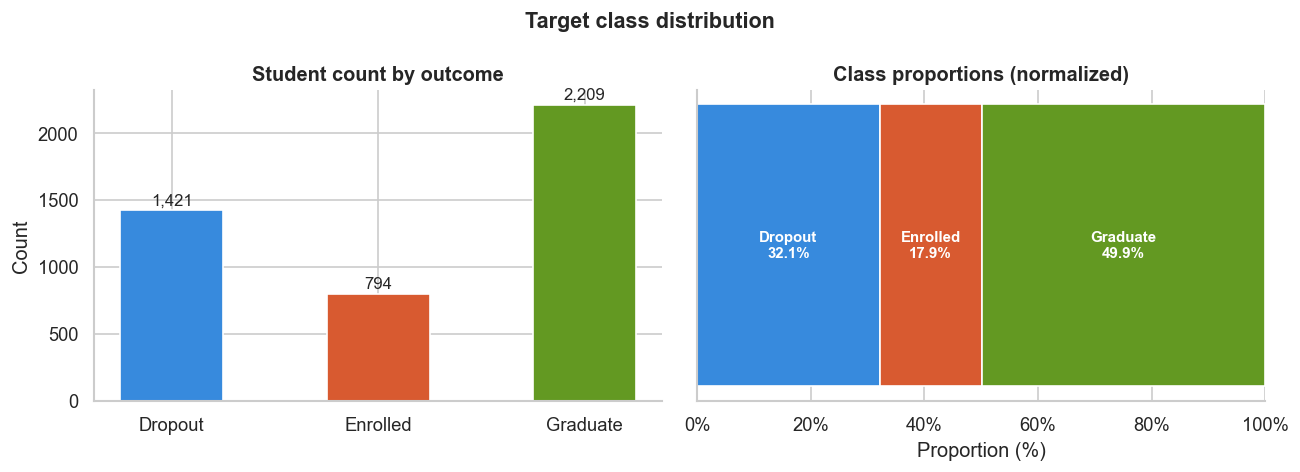


Implication: Graduate is the majority class at ~50%.
Enrolled is significantly underrepresented at ~18%.
Accuracy alone is misleading -- a model that always predicts Graduate gets 50%.
We will use per-class F1 and macro-averaged metrics, and address imbalance explicitly.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: count bar
bars = axes[0].bar(
    CLASS_ORDER,
    [class_counts[c] for c in CLASS_ORDER],
    color=[CLASS_COLORS[c] for c in CLASS_ORDER],
    width=0.5
)
axes[0].set_title('Student count by outcome', fontweight='bold')
axes[0].set_ylabel('Count')
for bar, cls in zip(bars, CLASS_ORDER):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f'{class_counts[cls]:,}',
        ha='center', va='bottom', fontsize=10
    )

# Right: normalized stacked bar
proportions = pd.DataFrame({
    'Class': CLASS_ORDER,
    'Proportion': [class_pct[c] for c in CLASS_ORDER]
})
left = 0
for cls in CLASS_ORDER:
    axes[1].barh(
        ['All students'],
        [class_pct[cls]],
        left=left,
        color=CLASS_COLORS[cls],
        label=cls,
        height=0.4
    )
    axes[1].text(
        left + class_pct[cls] / 2,
        0,
        f'{cls}\n{class_pct[cls]:.1f}%',
        ha='center', va='center',
        fontsize=9, color='white', fontweight='bold'
    )
    left += class_pct[cls]
axes[1].set_xlim(0, 100)
axes[1].set_xlabel('Proportion (%)')
axes[1].set_title('Class proportions (normalized)', fontweight='bold')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_yticks([])

plt.suptitle('Target class distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/eda_class_distribution.png', bbox_inches='tight')
plt.show()

print('\nImplication: Graduate is the majority class at ~50%.')
print('Enrolled is significantly underrepresented at ~18%.')
print('Accuracy alone is misleading -- a model that always predicts Graduate gets 50%.')
print('We will use per-class F1 and macro-averaged metrics, and address imbalance explicitly.')

## 3. Academic performance signals

Semester 1 performance is available at enrollment time (before dropout occurs), making it the most actionable feature set for early intervention.

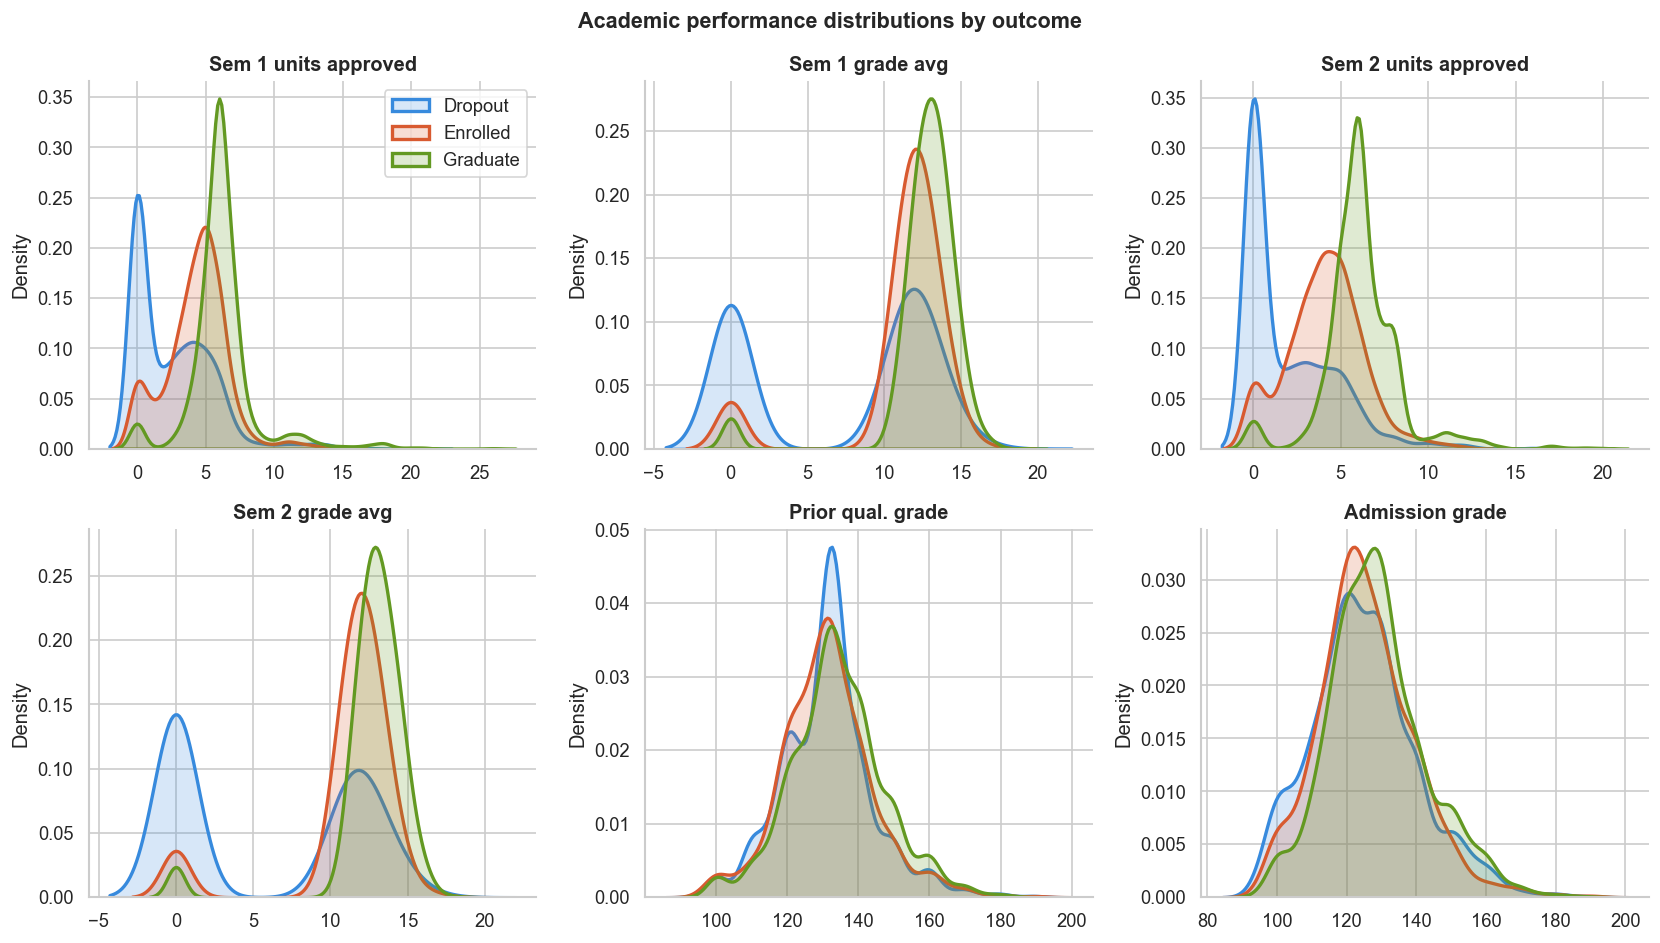

In [5]:
academic_features = [
    'sem1_units_approved', 'sem1_grade',
    'sem2_units_approved', 'sem2_grade',
    'previous_qualification_grade', 'admission_grade'
]

feature_labels = {
    'sem1_units_approved': 'Sem 1 units approved',
    'sem1_grade': 'Sem 1 grade avg',
    'sem2_units_approved': 'Sem 2 units approved',
    'sem2_grade': 'Sem 2 grade avg',
    'previous_qualification_grade': 'Prior qual. grade',
    'admission_grade': 'Admission grade'
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(academic_features):
    for cls in CLASS_ORDER:
        subset = df[df['outcome'] == cls][feat].dropna()
        sns.kdeplot(
            subset,
            ax=axes[i],
            color=CLASS_COLORS[cls],
            label=cls,
            linewidth=2,
            fill=True,
            alpha=0.2
        )
    axes[i].set_title(feature_labels[feat], fontweight='bold')
    axes[i].set_ylabel('Density')
    axes[i].set_xlabel('')
    if i == 0:
        axes[i].legend()

plt.suptitle('Academic performance distributions by outcome', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/eda_academic_distributions.png', bbox_inches='tight')
plt.show()


In [6]:
# Mean comparison table
summary = df.groupby('outcome')[academic_features].mean().round(2)
summary = summary.loc[CLASS_ORDER]
summary.columns = [feature_labels[c] for c in summary.columns]
print("Mean academic performance by outcome:")
print(summary.to_string())

Mean academic performance by outcome:
          Sem 1 units approved  Sem 1 grade avg  Sem 2 units approved  Sem 2 grade avg  Prior qual. grade  Admission grade
outcome                                                                                                                   
Dropout                   2.55             7.26                  1.94             5.90             131.11           124.96
Enrolled                  4.32            11.13                  4.06            11.12             131.21           125.53
Graduate                  6.23            12.64                  6.18            12.70             134.08           128.79


## 4. Financial signals, tuition and scholarship

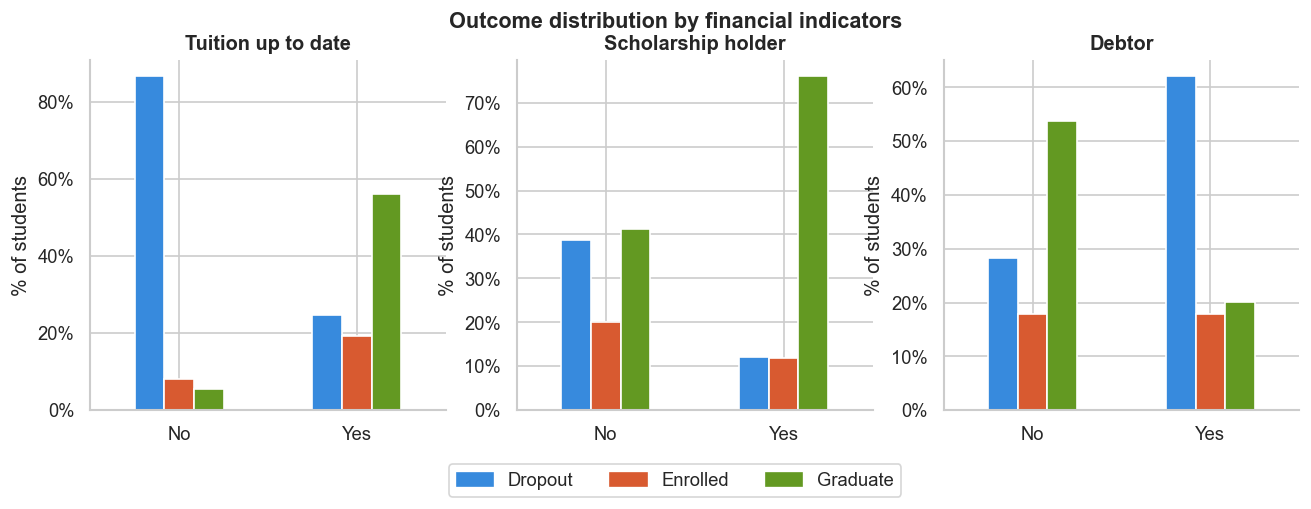

Dropout rate by tuition status:
  Not current: 86.6%
  Current: 24.7%


In [7]:
financial_features = ['tuition_fees_up_to_date', 'is_scholarship_holder', 'is_debtor']
financial_labels = {
    'tuition_fees_up_to_date': 'Tuition up to date',
    'is_scholarship_holder': 'Scholarship holder',
    'is_debtor': 'Debtor'
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for i, feat in enumerate(financial_features):
    rate = (
        df.groupby([feat, 'outcome'])
        .size()
        .unstack(fill_value=0)
        .apply(lambda x: x / x.sum() * 100, axis=1)
    )
    rate = rate[CLASS_ORDER]
    rate.index = ['No', 'Yes']
    rate.plot(
        kind='bar',
        ax=axes[i],
        color=[CLASS_COLORS[c] for c in CLASS_ORDER],
        width=0.5,
        legend=False
    )
    axes[i].set_title(financial_labels[feat], fontweight='bold')
    axes[i].set_ylabel('% of students')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())

# Define handles then add shared legend below the subplots
handles = [plt.Rectangle((0, 0), 1, 1, color=CLASS_COLORS[c]) for c in CLASS_ORDER]
fig.legend(
    handles, CLASS_ORDER,
    loc='lower center',
    ncol=3,
    bbox_to_anchor=(0.5, -0.05),
    framealpha=0.8
)

plt.suptitle('Outcome distribution by financial indicators', fontsize=13, fontweight='bold')
plt.subplots_adjust(bottom=0.15)
plt.savefig('../data/eda_financial_signals.png', bbox_inches='tight')
plt.show()

# Dropout rate summary
print("Dropout rate by tuition status:")
for val, label in [(0, 'Not current'), (1, 'Current')]:
    subset = df[df['tuition_fees_up_to_date'] == val]
    rate = (subset['outcome'] == 'Dropout').mean() * 100
    print(f"  {label}: {rate:.1f}%")

## 5. Dropout rate by course

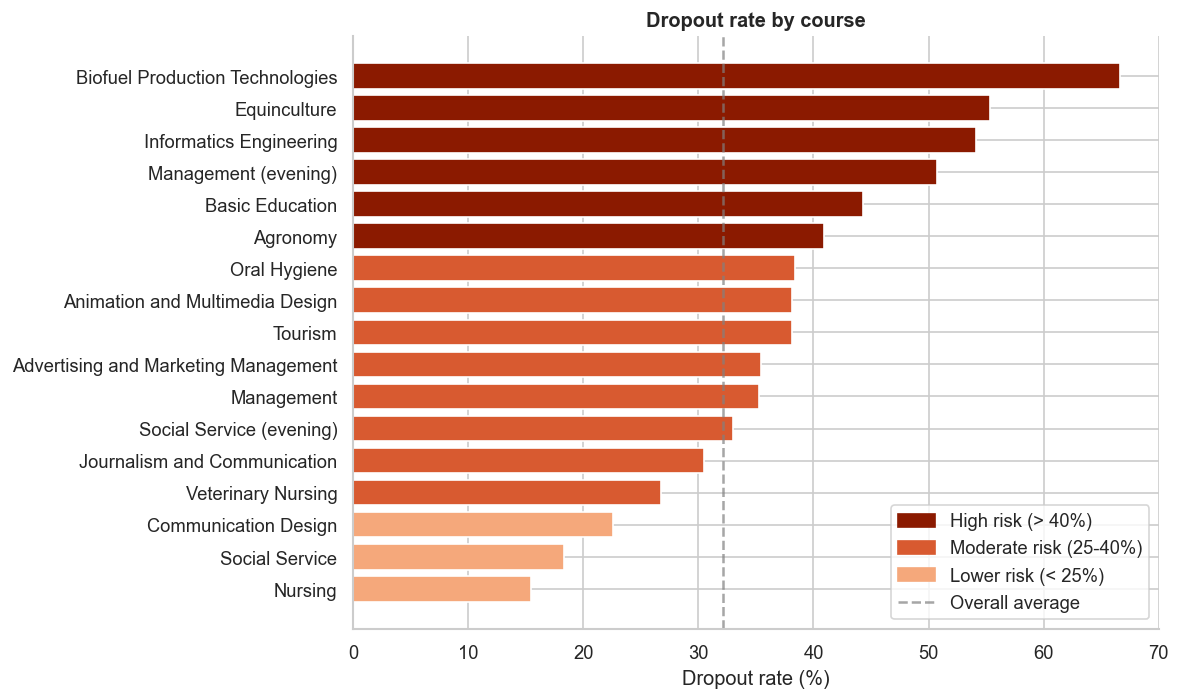

In [8]:
course_stats = (
    df.groupby('course_name')['outcome']
    .apply(lambda x: (x == 'Dropout').mean() * 100)
    .sort_values(ascending=True)
    .reset_index()
)
course_stats.columns = ['course_name', 'dropout_rate']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    course_stats['course_name'],
    course_stats['dropout_rate'],
    color=[
            '#8B1A00' if r > 40
            else '#D85A30' if r > 25
            else '#F5A87B'
            for r in course_stats['dropout_rate']
        ]
)
ax.axvline(
    x=df['outcome'].eq('Dropout').mean() * 100,
    color='gray', linestyle='--', alpha=0.7
)

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color='#8B1A00', label='High risk (> 40%)'),
    plt.Rectangle((0, 0), 1, 1, color='#D85A30', label='Moderate risk (25-40%)'),
    plt.Rectangle((0, 0), 1, 1, color='#F5A87B', label='Lower risk (< 25%)'),
    plt.Line2D([0], [0], color='gray', linestyle='--', alpha=0.7, label='Overall average'),
]
ax.legend(handles=legend_handles, loc='lower right', framealpha=0.8)

ax.set_xlabel('Dropout rate (%)')
ax.set_title('Dropout rate by course', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/eda_dropout_by_course.png', bbox_inches='tight')
plt.show()

## 6. Approval rate, derived feature signal

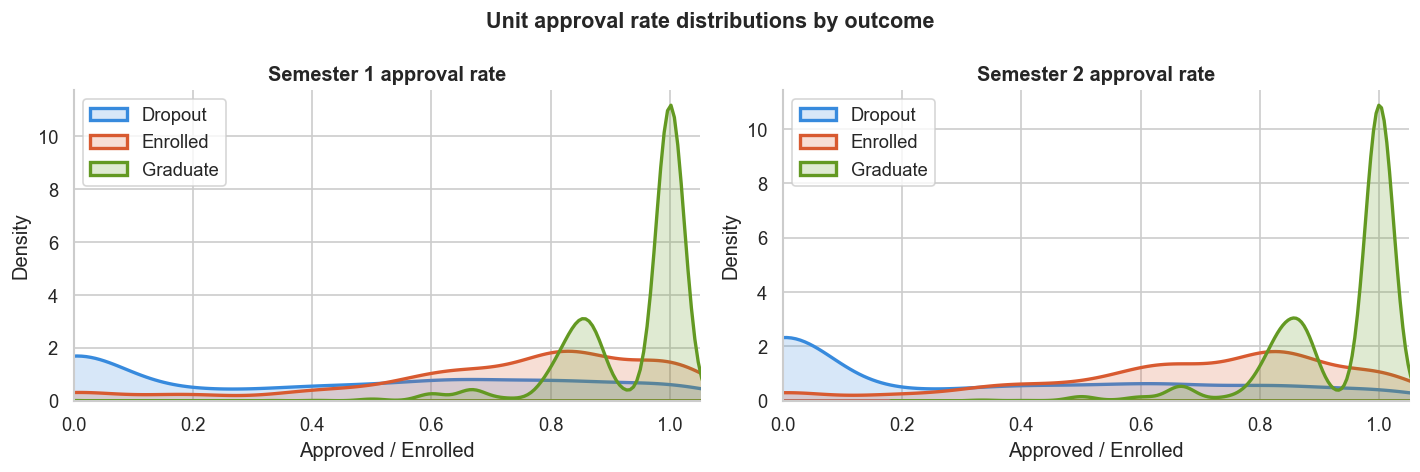

Mean approval rates by outcome:
          sem1_approval_rate  sem2_approval_rate
outcome                                         
Dropout                0.406               0.310
Enrolled               0.714               0.673
Graduate               0.935               0.932


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, feat in enumerate(['sem1_approval_rate', 'sem2_approval_rate']):
    for cls in CLASS_ORDER:
        subset = df[df['outcome'] == cls][feat].dropna()
        sns.kdeplot(
            subset,
            ax=axes[i],
            color=CLASS_COLORS[cls],
            label=cls,
            linewidth=2,
            fill=True,
            alpha=0.2
        )
    axes[i].set_title(f'{"Semester 1" if i == 0 else "Semester 2"} approval rate', fontweight='bold')
    axes[i].set_xlabel('Approved / Enrolled')
    axes[i].set_ylabel('Density')
    axes[i].set_xlim(0, 1.05)
    axes[i].legend()

plt.suptitle('Unit approval rate distributions by outcome', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/eda_approval_rates.png', bbox_inches='tight')
plt.show()

print("Mean approval rates by outcome:")
print(df.groupby('outcome')[['sem1_approval_rate', 'sem2_approval_rate']].mean().round(3).loc[CLASS_ORDER])

## 7. Correlation structure

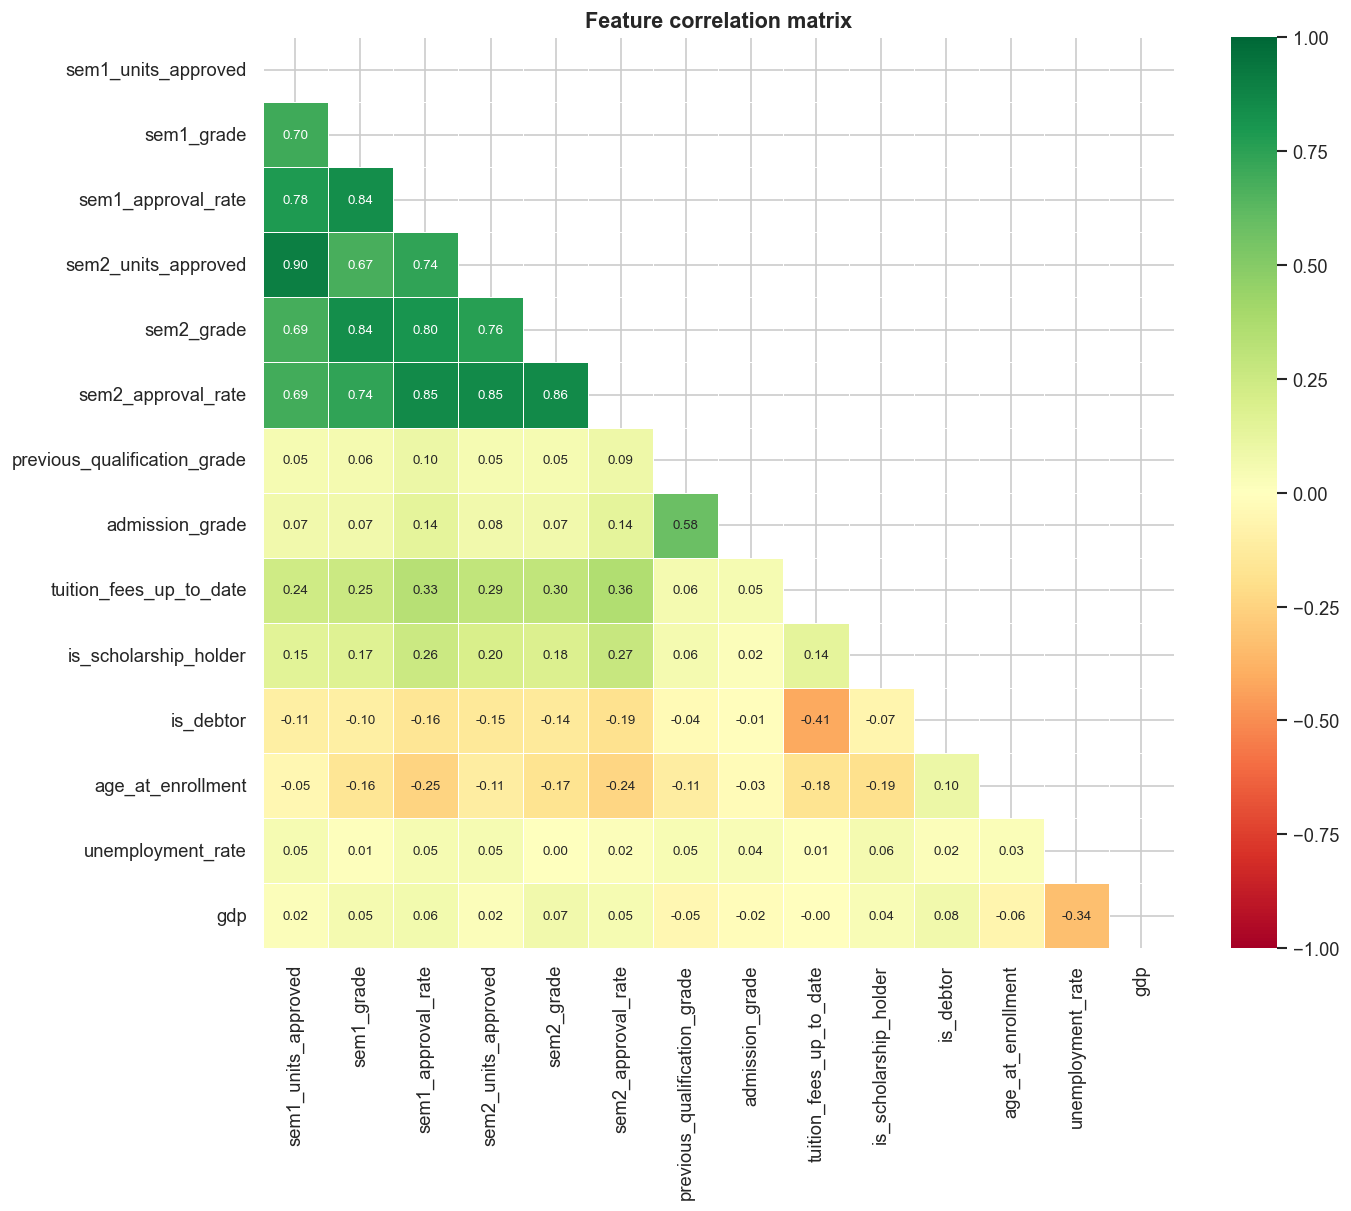

In [10]:
numeric_features = [
    'sem1_units_approved', 'sem1_grade', 'sem1_approval_rate',
    'sem2_units_approved', 'sem2_grade', 'sem2_approval_rate',
    'previous_qualification_grade', 'admission_grade',
    'tuition_fees_up_to_date', 'is_scholarship_holder', 'is_debtor',
    'age_at_enrollment', 'unemployment_rate', 'gdp'
]

corr = df[numeric_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Feature correlation matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../data/eda_correlation_matrix.png', bbox_inches='tight')
plt.show()

## 8. EDA summary, modeling implications

Key findings and their downstream impact on modeling decisions.

In [13]:
print("=" * 65)
print("EDA SUMMARY -- MODELING IMPLICATIONS")
print("=" * 65)

print("""
1. CLASS IMBALANCE
   Graduate ~50%, Dropout ~32%, Enrolled ~18%.
   -> Use macro-averaged F1, not accuracy, as primary metric.
   -> Apply class_weight='balanced' or SMOTE in notebook 02.
   -> Enrolled will be the hardest class to predict.

2. STRONGEST DROPOUT SIGNALS
   -> Tuition not current: dramatically elevated dropout rate.
   -> Semester 1 units approved: dropouts approve far fewer units.
   -> Semester 1 grade: clear separation between Dropout and Graduate.
   -> Approval rate (derived): strong signal, especially sem1.
   -> Dropout approval rate is broadly flat from 0.0 to 0.6 with no
      strong concentration, indicating diffuse underperformance rather
      than a single failure threshold.
   -> Graduate approval rate is bimodal: dominant spike at 1.0 and a
      secondary peak near 0.85, suggesting most graduates approved all
      units but a subset succeeded with slightly lower rates.

3. FEATURE ENGINEERING TARGETS (notebook 02)
   -> sem1_approval_rate already derived in dbt mart.
   -> Consider: combined_sem_grade, units_delta (sem2 - sem1).
   -> sem1 features more actionable than sem2 for early intervention.

4. COLLINEARITY NOTES
   -> Sem1/sem2 features form a highly correlated cluster (r=0.69-0.90).
   -> Tuition and is_debtor are negatively correlated (r=-0.41).
   -> Unemployment and GDP are negatively correlated (r=-0.34).
   -> Admission grade and prior qualification grade are moderately
      correlated (r=0.58) -- admission_grade dropped in notebook 02,
      prior qualification grade retained as the stronger signal.
   -> Age at enrollment shows negative correlation with approval rates
      (r=-0.25 with sem1_approval_rate) -- older students at enrollment
      tend to underperform slightly. Feature retained for modeling.

5. LOW SIGNAL FEATURES
   -> Macroeconomic features (GDP, unemployment, inflation) show
      weak individual signal -- may contribute marginally in ensemble.
   -> is_debtor shows weak correlations across academic features,
      but is captured indirectly via the financial_stress interaction
      term engineered in notebook 02.
""")

EDA SUMMARY -- MODELING IMPLICATIONS

1. CLASS IMBALANCE
   Graduate ~50%, Dropout ~32%, Enrolled ~18%.
   -> Use macro-averaged F1, not accuracy, as primary metric.
   -> Apply class_weight='balanced' or SMOTE in notebook 02.
   -> Enrolled will be the hardest class to predict.

2. STRONGEST DROPOUT SIGNALS
   -> Tuition not current: dramatically elevated dropout rate.
   -> Semester 1 units approved: dropouts approve far fewer units.
   -> Semester 1 grade: clear separation between Dropout and Graduate.
   -> Approval rate (derived): strong signal, especially sem1.
   -> Dropout approval rate is broadly flat from 0.0 to 0.6 with no
      strong concentration, indicating diffuse underperformance rather
      than a single failure threshold.
   -> Graduate approval rate is bimodal: dominant spike at 1.0 and a
      secondary peak near 0.85, suggesting most graduates approved all
      units but a subset succeeded with slightly lower rates.

3. FEATURE ENGINEERING TARGETS (notebook 02)
